# **EQUIPO LFM** | Aprendizaje automatico

## Bibliotecas a utilizar en el cuaderno

In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ShuffleSplit, cross_val_score

Creación de un dataframe a partir del archivo csv

In [275]:
dfIris = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSLgU6YF5djPgcJvcmXyqdIjfVefPsYlj6HUnRH15sZwsEL4GX7KPY-c3CWgM3n8vCljid-ZPocdAAl/pub?output=csv')

## Preprocesamiento

### Feature Scaling
- No se hace uso de un StandardScaler o MinMaxScaler para unificar las escalas porque en el dataset estas ya estan informadas en la misma escala (centímetros).

### Header standarization & data cleaning

- Renombraremos las columnas al español, y eliminaremos la columan Id ya que no será utilizada para el análisis

In [276]:
#Renombrado de columnas
dfIris.rename({'SepalLengthCm':'sepalo_largo',
           'SepalWidthCm':'sepalo_ancho',
           'PetalLengthCm':'petalo_largo',
           'PetalWidthCm':'petalo_ancho',
           'Species':'especies'},
          axis=1, inplace=True) # inplace = True para que el renombrado sea sobre el mismo df

dfIris.drop('Id', axis=1, inplace=True) #axis=1 indica que es una columna


Inspección de la forma del df

In [277]:
dfIris.shape

(150, 5)

Visualización del segmento inicial y final de los datos

In [278]:
dfIris

,sepalo_largo,sepalo_ancho,petalo_largo,petalo_ancho,especies
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Matriz de Correlación

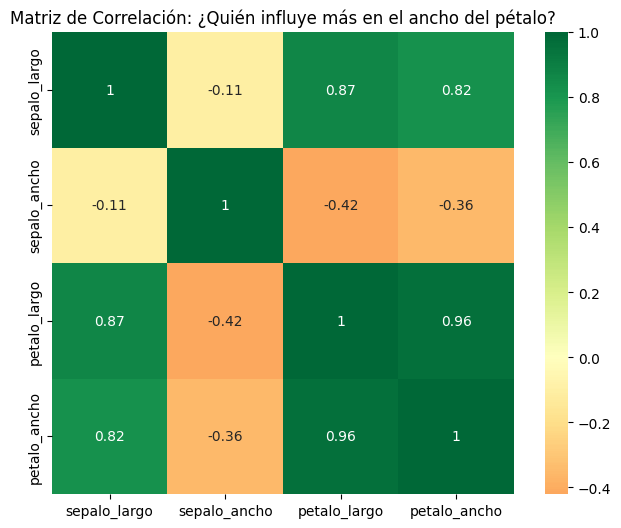

In [279]:
# 1. Calculamos la correlación de las columnas numéricas
matriz_corr = dfIris.drop(columns=['especies']).corr()

# 2. Generamos el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', center=0, square=True)

plt.title('Matriz de Correlación: ¿Quién influye más en el ancho del pétalo?')
plt.show()

### Conclusiones parciales:

- Largo del pétalo: Según se observa en la matriz de correlación es la variable con mayor correlación.
- Largo del sépalo: Esta variable también tiene una alta correlación con el ancho del petalo.
- Ancho del sépalo: Esta variable tiene una correlación muy baja e incluso negativa.

Estas correlaciones analíticas tienen coherencia biológica, dado que los petalos crecen en ambas direcciones, a lo largo y a lo ancho. A su vez, los sépalos (cáliz, exterior) y pétalos (corola, interior) son hojas modificadas que forman el perianto que tiene una función de protección de los organos sexuales y de atracción de polinizadores y en el desarrollo temprano del capullo, los sépalos actúan como cobertura protectora del pétalo.

## Estudio del impacto de la dimensionalidad

Se procede a entrenar modelos con cantidades diferentes sucesivas de dimensiones y evaluar su rendimiento.



## Tres dimensiones

- Largo del pétalo
- Largo del sépalo
- Ancho del sépalo



### Particionamiento

In [280]:
X = dfIris.drop(['petalo_ancho', 'especies'], axis=1)
y = dfIris['petalo_ancho']

In [281]:
# 2. División en entrenamiento y prueba
X_train3, X_test3, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Búsqueda de K óptimo - Holdout - K vs MSE

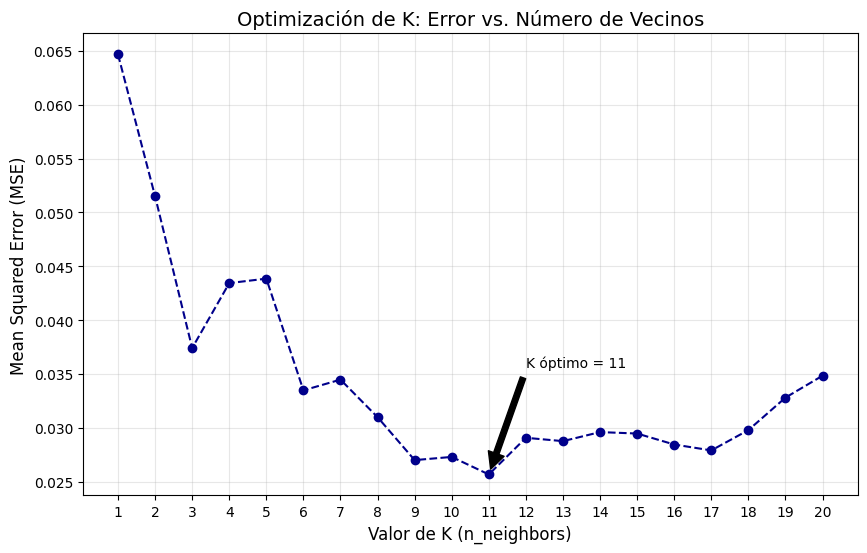

In [282]:
# @title
k_values = range(1, 21) # Probamos k desde 1 hasta 20
errores_mse = []

for k in k_values:
    # Entrenar modelo con el k actual
    modelo = KNeighborsRegressor(n_neighbors=k)
    modelo.fit(X_train3, y_train)

    # Predecir y calcular el error
    predicciones = modelo.predict(X_test3)
    mse = mean_squared_error(y_test, predicciones)
    errores_mse.append(mse)

# Guardar resultados y graficar
resultados = pd.DataFrame({'k': k_values, 'MSE': errores_mse})

plt.figure(figsize=(10, 6))
plt.plot(k_values, errores_mse, marker='o', linestyle='--', color='darkblue')

# Estética del gráfico
plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(k_values) # Para ver todos los números del 1 al 20
plt.grid(True, alpha=0.3)

# Marcar el punto óptimo
min_mse = min(errores_mse)
best_k = k_values[errores_mse.index(min_mse)]
plt.annotate(f'K óptimo = {best_k}',
             xy=(best_k, min_mse),
             xytext=(best_k + 1, min_mse + 0.01),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

### Búsqueda de K óptimo - Holdout - K vs R^2

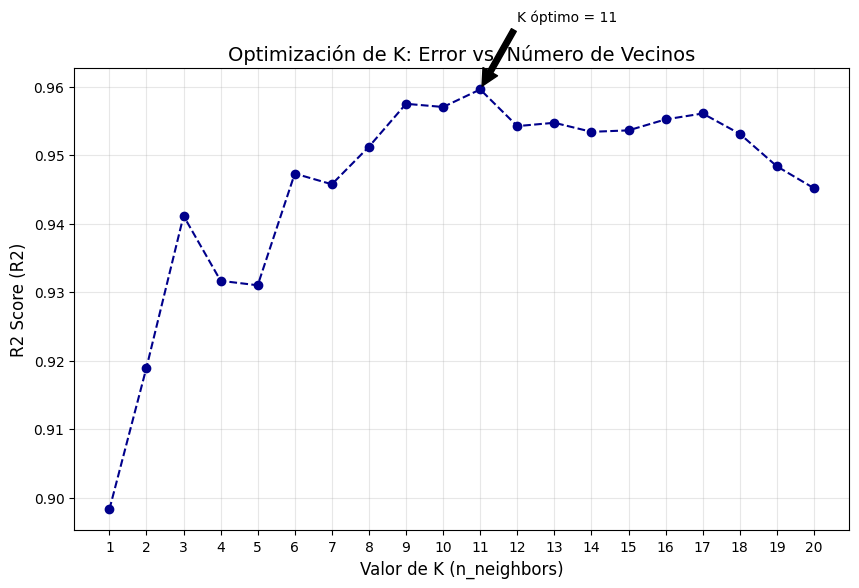

In [283]:
k_values = range(1, 21) # Probamos k desde 1 hasta 20
errores_r2 = []

for k in k_values:
    # Entrenar modelo con el k actual
    modelo = KNeighborsRegressor(n_neighbors=k)
    modelo.fit(X_train3, y_train)

    # Predecir y calcular el error
    predicciones = modelo.fit(X_train3, y_train).predict(X_test3)
    r2 = r2_score(y_test, predicciones)
    errores_r2.append(r2)

# Guardar resultados y graficar
resultados = pd.DataFrame({'k': k_values, 'MSE': errores_r2})

plt.figure(figsize=(10, 6))
plt.plot(k_values, errores_r2, marker='o', linestyle='--', color='darkblue')

# Estética del gráfico
plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
plt.ylabel('R2 Score (R2)', fontsize=12)
plt.xticks(k_values) # Para ver todos los números del 1 al 20
plt.grid(True, alpha=0.3)

# Marcar el punto óptimo
max_r2 = max(errores_r2)
best_k = k_values[errores_r2.index(max_r2)]
plt.annotate(f'K óptimo = {best_k}',
             xy=(best_k, max_r2),
             xytext=(best_k + 1, max_r2 + 0.01),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

### Implementación de KNN Regresor

In [284]:
knn = KNeighborsRegressor(n_neighbors=11, p=2, weights='distance')
knn.fit(X_train3, y_train)
X_train3

,sepalo_largo,sepalo_ancho,petalo_largo
22,4.6,3.6,1.0
15,5.7,4.4,1.5
65,6.7,3.1,4.4
11,4.8,3.4,1.6
42,4.4,3.2,1.3
...,...,...,...
71,6.1,2.8,4.0
106,4.9,2.5,4.5
14,5.8,4.0,1.2
92,5.8,2.6,4.0


### Predicciones

In [285]:
y_pred3 = knn.predict(X_test3)

### Evaluación del modelo - Resultados

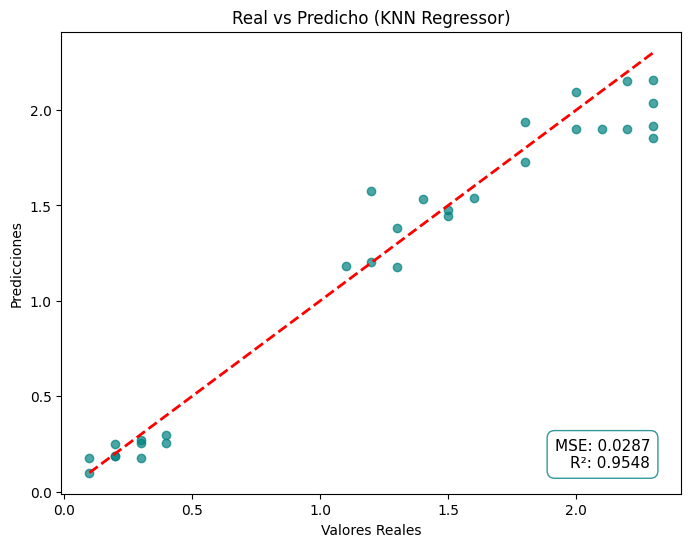

In [286]:
# 1. Cálculo de métricas
mse = mean_squared_error(y_test, y_pred3)
r2 = r2_score(y_test, y_pred3)

# 2. Generación del gráfico
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred3, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

# Configuración de etiquetas
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicho (KNN Regressor)')

# 3. Agregar el cuadro de texto "dentro" del gráfico (esquina inferior derecha)
texto_metricas = f"MSE: {mse:.4f}\nR²: {r2:.4f}"

# Usamos plt.gca().text para posicionar el texto
# transform=plt.gca().transAxes asegura que (1,0) sea la esquina inferior derecha exacta
plt.gca().text(0.95, 0.05, texto_metricas,
               transform=plt.gca().transAxes,
               fontsize=11,
               verticalalignment='bottom',
               horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='teal'))

plt.show()

## Dos dimensiones
Solo petalo largo y sepalo ancho.

In [287]:
X2 = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_largo'], axis=1)
# y = dfIris['petalo_ancho']

In [288]:
# 2. División en entrenamiento y prueba
X_train2, X_test2, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

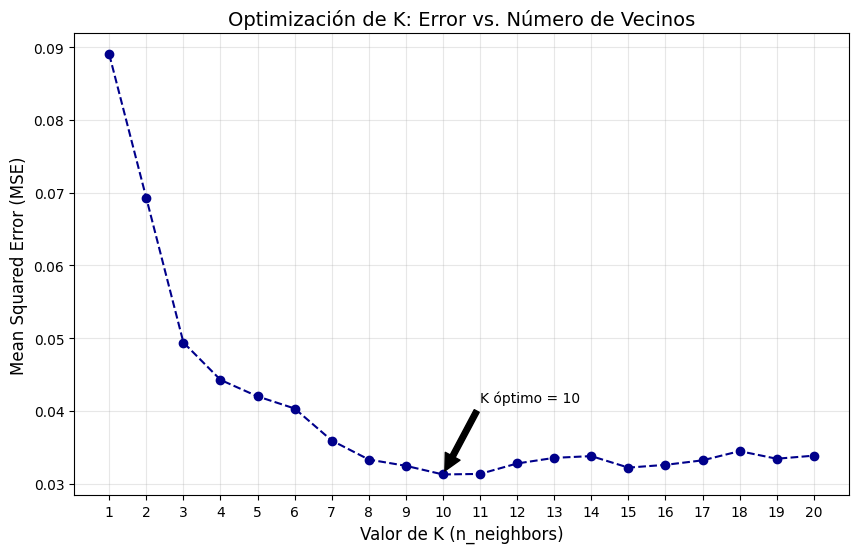

In [289]:
# @title
k_values = range(1, 21) # Probamos k desde 1 hasta 20
errores_mse = []

for k in k_values:
    # Entrenar modelo con el k actual
    modelo = KNeighborsRegressor(n_neighbors=k)
    modelo.fit(X_train2, y_train)

    # Predecir y calcular el error
    predicciones = modelo.predict(X_test2)
    mse = mean_squared_error(y_test, predicciones)
    errores_mse.append(mse)

# Guardar resultados y graficar
resultados = pd.DataFrame({'k': k_values, 'MSE': errores_mse})

plt.figure(figsize=(10, 6))
plt.plot(k_values, errores_mse, marker='o', linestyle='--', color='darkblue')

# Estética del gráfico
plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(k_values) # Para ver todos los números del 1 al 20
plt.grid(True, alpha=0.3)

# Marcar el punto óptimo
min_mse = min(errores_mse)
best_k = k_values[errores_mse.index(min_mse)]
plt.annotate(f'K óptimo = {best_k}',
             xy=(best_k, min_mse),
             xytext=(best_k + 1, min_mse + 0.01),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

#### Búsqueda de K óptimo - Holdout - K vs R^2

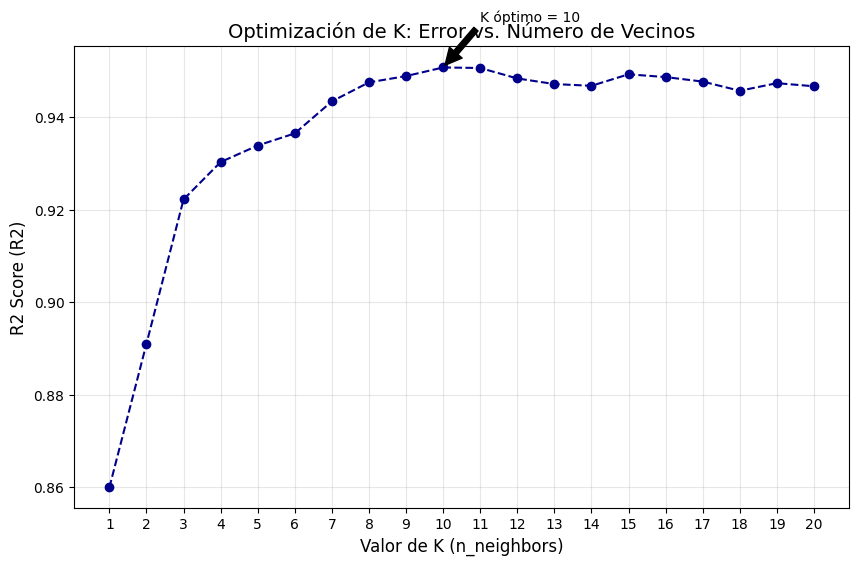

In [290]:
k_values = range(1, 21) # Probamos k desde 1 hasta 20
errores_r2 = []

for k in k_values:
    # Entrenar modelo con el k actual
    modelo = KNeighborsRegressor(n_neighbors=k)
    modelo.fit(X_train2, y_train)

    # Predecir y calcular el error
    predicciones = modelo.fit(X_train2, y_train).predict(X_test2)
    r2 = r2_score(y_test, predicciones)
    errores_r2.append(r2)

# Guardar resultados y graficar
resultados = pd.DataFrame({'k': k_values, 'MSE': errores_r2})

plt.figure(figsize=(10, 6))
plt.plot(k_values, errores_r2, marker='o', linestyle='--', color='darkblue')

# Estética del gráfico
plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
plt.ylabel('R2 Score (R2)', fontsize=12)
plt.xticks(k_values) # Para ver todos los números del 1 al 20
plt.grid(True, alpha=0.3)

# Marcar el punto óptimo
max_r2 = max(errores_r2)
best_k = k_values[errores_r2.index(max_r2)]
plt.annotate(f'K óptimo = {best_k}',
             xy=(best_k, max_r2),
             xytext=(best_k + 1, max_r2 + 0.01),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

### Implementación KNN Regressor

In [291]:
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train2, y_train)

KNeighborsRegressor(n_neighbors=10)

### Predicciones

In [292]:
y_pred2 = knn.predict(X_test2)

### Evaluación del modelo - Resultados

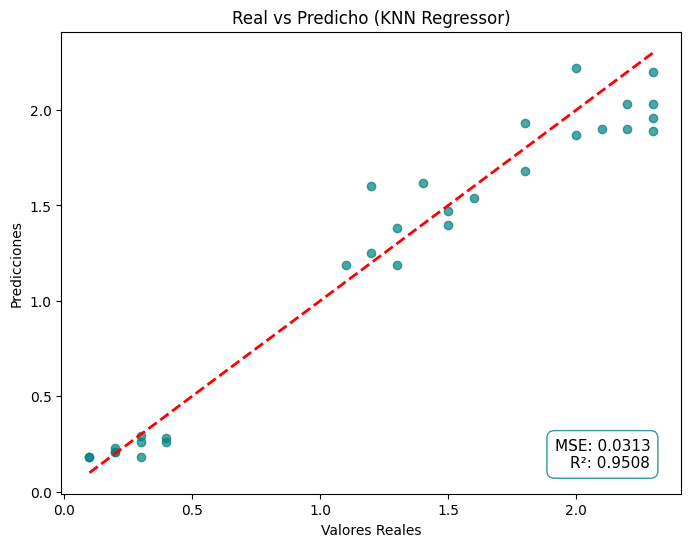

Resultados KNN:
Mean Squared Error: 0.0313
R² Score: 0.9508


In [293]:
# 1. Cálculo de métricas
mse = mean_squared_error(y_test, y_pred2)
r2 = r2_score(y_test, y_pred2)

# 2. Generación del gráfico
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred2, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

# Configuración de etiquetas
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicho (KNN Regressor)')

# 3. Se agrega el cuadro de texto "dentro" del gráfico (esquina inferior derecha)
texto_metricas = f"MSE: {mse:.4f}\nR²: {r2:.4f}"

# Usamos plt.gca().text para posicionar el texto
# transform=plt.gca().transAxes asegura que (1,0) sea la esquina inferior derecha exacta
plt.gca().text(0.95, 0.05, texto_metricas,
               transform=plt.gca().transAxes,
               fontsize=11,
               verticalalignment='bottom',
               horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='teal'))

plt.show()

print(f"Resultados KNN:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


## Una dimension
Solo petalo largo y sepalo ancho.

In [294]:
X1 = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_largo', 'sepalo_ancho'], axis=1)
# y = dfIris['petalo_ancho']

In [295]:
# 2. División en entrenamiento y prueba
X_train1, X_test1, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

In [296]:
knn = KNeighborsRegressor(n_neighbors=11)
knn.fit(X_train1, y_train)

KNeighborsRegressor(n_neighbors=11)

In [297]:
y_pred1 = knn.predict(X_test1)

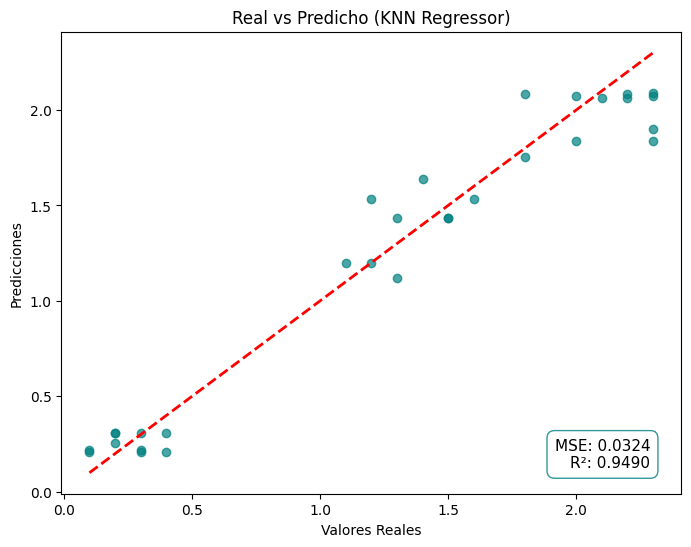

Resultados KNN:
Mean Squared Error: 0.0324
R² Score: 0.9490


In [298]:
# 1. Cálculo de métricas
mse = mean_squared_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred1)

# 2. Generación del gráfico
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred1, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

# Configuración de etiquetas
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicho (KNN Regressor)')

# 3. Se agrega el cuadro de texto "dentro" del gráfico (esquina inferior derecha)
texto_metricas = f"MSE: {mse:.4f}\nR²: {r2:.4f}"

# Usamos plt.gca().text para posicionar el texto
# transform=plt.gca().transAxes asegura que (1,0) sea la esquina inferior derecha exacta
plt.gca().text(0.95, 0.05, texto_metricas,
               transform=plt.gca().transAxes,
               fontsize=11,
               verticalalignment='bottom',
               horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='teal'))

plt.show()

print(f"Resultados KNN:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Conclusiones grales:

**El problema de la multi-colinealidad en la multi-dimensinalidad:**

Como KNN calcula distancias en un espacio multidimensional, al agregar dos dimensiones que tienen alta colinealidad (como largo del pétalo y largo del sépalo) esto hace que la información se vuelva redundante y el cálculo de la distancia euclidiana (Minkowski p=2 por defecto en Scikit learn) se vea "arrastrado" doblemente por la misma tendencia subyacente. Asi el algoritmo resulta menos sensible a variables de menor correlación como el ancho del sépalo. Es decir, la predicción termina dependiendo excesivamente de la magnitud de la longitud.